In [1]:
%pip install numpy pandas matplotlib scikit-learn scipy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import ctypes, os, subprocess, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.linalg import eigh
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

np.random.seed(42)
print("Imports OK")

/home/mohamed/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Imports OK


In [4]:
SERIAL_DIR   = 'serial'
PARALLEL_DIR = 'parallel'

def compile_lib(directory, target):
    result = subprocess.run(['make', '-C', directory, '-B'],
                            capture_output=True, text=True)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError(f'Compilation failed in {directory}')
    path = os.path.join(directory, target)
    return os.path.abspath(path)

serial_so   = compile_lib(SERIAL_DIR,   'lda_serial.so')
parallel_so = compile_lib(PARALLEL_DIR, 'lda_openmp.so')

print("Compilation OK")

Compilation OK


In [26]:
# ── type aliases ──────────────────────────────────────────────────────────────
c_double_p = ctypes.POINTER(ctypes.c_double)
c_int_p    = ctypes.POINTER(ctypes.c_int)

# ── helpers ───────────────────────────────────────────────────────────────────
def dptr(arr):
    """Pointer vers tableau float64"""
    return arr.ctypes.data_as(c_double_p)

def iptr(arr):
    """Pointer vers tableau int32"""
    return arr.ctypes.data_as(c_int_p)

def _bind(lib, name, argtypes, restype=None):
    """Bind une fonction C"""
    fn = getattr(lib, name)
    fn.argtypes = argtypes
    fn.restype  = restype if restype else ctypes.c_double
    return fn


# ── serial ────────────────────────────────────────────────────────────────────
_serial = ctypes.CDLL(serial_so)

_serial_means = _bind(_serial, 'compute_class_means',
    [c_double_p, c_int_p,
     ctypes.c_int, ctypes.c_int, ctypes.c_int,
     c_double_p, c_int_p, c_double_p],
    restype=None)

_serial_sw = _bind(_serial, 'compute_sw',
    [c_double_p, c_int_p, c_double_p,
     ctypes.c_int, ctypes.c_int, ctypes.c_int,
     c_double_p])

_serial_sb = _bind(_serial, 'compute_sb',
    [c_double_p, c_double_p, c_int_p,
     ctypes.c_int, ctypes.c_int,
     c_double_p],
    restype=None)

_serial_proj = _bind(_serial, 'lda_project',
    [c_double_p, c_double_p,
     ctypes.c_int, ctypes.c_int, ctypes.c_int,
     c_double_p],
    restype=None)


# ── parallel ──────────────────────────────────────────────────────────────────
_par = ctypes.CDLL(parallel_so)

_par_means = _bind(_par, 'compute_class_means',
    [c_double_p, c_int_p,
     ctypes.c_int, ctypes.c_int, ctypes.c_int,
     c_double_p, c_int_p, c_double_p],
    restype=None)

_par_sw = _bind(_par, 'compute_sw_parallel',
    [c_double_p, c_int_p, c_double_p,
     ctypes.c_int, ctypes.c_int, ctypes.c_int,
     c_double_p, ctypes.c_int])

_par_sb = _bind(_par, 'compute_sb',
    [c_double_p, c_double_p, c_int_p,
     ctypes.c_int, ctypes.c_int,
     c_double_p],
    restype=None)

_par_proj = _bind(_par, 'lda_project',
    [c_double_p, c_double_p,
     ctypes.c_int, ctypes.c_int, ctypes.c_int,
     c_double_p],
    restype=None)


print("ctypes bindings OK (serial + parallel)")

ctypes bindings OK (serial + parallel)


In [ ]:
# Cell 4
DATA_DIR = 'data'

train_df = pd.read_csv(f'{DATA_DIR}/train.csv')
test_df  = pd.read_csv(f'{DATA_DIR}/test.csv')

print(train_df.shape, test_df.shape)

7352 561 6 5


In [7]:
le = LabelEncoder()

X_train = train_df.drop(columns=['subject','Activity']).values.astype(np.float64)
y_train = le.fit_transform(train_df['Activity']).astype(np.int32)

X_test  = test_df.drop(columns=['subject','Activity']).values.astype(np.float64)
y_test  = le.transform(test_df['Activity']).astype(np.int32)

n, d = X_train.shape
C    = len(le.classes_)
K    = C - 1

print(n, d, C, K)

7352 561 6 5


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

#  PCA before LDA (VERY IMPORTANT)
pca = PCA(n_components=150)
X_train = pca.fit_transform(X_train)
X_test  = pca.transform(X_test)

d = X_train.shape[1]

print("Scaling + PCA OK → new d =", d)

Scaling + PCA OK → new d = 150


In [9]:
def run_serial_lda(X, y, n, d, C):

    means       = np.zeros((C, d))
    counts      = np.zeros(C, dtype=np.int32)
    global_mean = np.zeros(d)
    SW          = np.zeros((d, d))
    SB          = np.zeros((d, d))

    _serial_means(dptr(X), iptr(y), n, d, C,
                  dptr(means), iptr(counts), dptr(global_mean))

    t_sw = _serial_sw(dptr(X), iptr(y), dptr(means),
                      n, d, C, dptr(SW))

    _serial_sb(dptr(means), dptr(global_mean), iptr(counts),
               d, C, dptr(SB))

    # 🔥 meilleur régularisation
    SW_reg = SW + 1e-3 * np.eye(d)

    eigenvalues, eigenvectors = eigh(SB, SW_reg)

    W = eigenvectors[:, -K:]
    W = W[:, ::-1]

    W = W / (np.linalg.norm(W, axis=0) + 1e-12)

    return W, SW, SB, t_sw

In [10]:
def run_parallel_lda(X, y, n, d, C, num_threads):

    means       = np.zeros((C, d))
    counts      = np.zeros(C, dtype=np.int32)
    global_mean = np.zeros(d)
    SW          = np.zeros((d, d))
    SB          = np.zeros((d, d))

    _par_means(dptr(X), iptr(y),
               n, d, C,
               dptr(means), iptr(counts), dptr(global_mean))

    t_sw = _par_sw(dptr(X), iptr(y), dptr(means),
                   n, d, C,
                   dptr(SW), num_threads)

    _par_sb(dptr(means), dptr(global_mean), iptr(counts),
            d, C, dptr(SB))

    SW_reg = SW + 1e-3 * np.eye(d)

    eigenvalues, eigenvectors = eigh(SB, SW_reg)

    W = eigenvectors[:, -K:]
    W = W[:, ::-1]

    W = W / (np.linalg.norm(W, axis=0) + 1e-12)

    return W, SW, SB, t_sw

In [11]:
W_serial, SW_s, SB_s, t_sw_serial = run_serial_lda(X_train, y_train, n, d, C)

W_par4, SW_p4, _, t_sw_par4 = run_parallel_lda(X_train, y_train, n, d, C, 4)

print("Serial time:", t_sw_serial)
print("Parallel time:", t_sw_par4)

Serial time: 0.0835871870003757
Parallel time: 0.04610310800126172


In [12]:
assert SW_s.shape == SW_p4.shape

max_diff = np.max(np.abs(SW_s - SW_p4))
rel_diff = max_diff / (np.max(np.abs(SW_s)) + 1e-15)

print("Max diff:", max_diff)
print("Rel diff:", rel_diff)

assert rel_diff < 1e-10, "❌ Parallel incorrect"
print("✅ Parallel correct")

Max diff: 2.6193447411060333e-10
Rel diff: 1.0059432053730604e-15
✅ Parallel correct


In [13]:
Y_train = X_train @ W_serial
Y_test  = X_test  @ W_serial

print(Y_train.shape, Y_test.shape)

(7352, 5) (2947, 5)


In [14]:
knn = KNeighborsClassifier(n_neighbors=3)  # 🔥 better than 1
knn.fit(Y_train, y_train)

y_pred = knn.predict(Y_test)

acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)
print(classification_report(y_test, y_pred))

Accuracy: 0.9406175771971497
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       537
           1       0.90      0.88      0.89       491
           2       0.89      0.91      0.90       532
           3       0.92      0.98      0.95       496
           4       0.98      0.94      0.96       420
           5       0.96      0.93      0.94       471

    accuracy                           0.94      2947
   macro avg       0.94      0.94      0.94      2947
weighted avg       0.94      0.94      0.94      2947



In [15]:
# Projection avec W serial
Y_train_serial = X_train @ W_serial
Y_test_serial  = X_test  @ W_serial

print("Projected (serial):", Y_train_serial.shape, Y_test_serial.shape)

Projected (serial): (7352, 5) (2947, 5)


In [16]:
knn_serial = KNeighborsClassifier(n_neighbors=3)

knn_serial.fit(Y_train_serial, y_train)
y_pred_serial = knn_serial.predict(Y_test_serial)

acc_serial = accuracy_score(y_test, y_pred_serial)

print("=== SERIAL ===")
print(f"Accuracy: {acc_serial:.4f} ({acc_serial*100:.2f}%)")
print(classification_report(y_test, y_pred_serial))

=== SERIAL ===
Accuracy: 0.9406 (94.06%)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       537
           1       0.90      0.88      0.89       491
           2       0.89      0.91      0.90       532
           3       0.92      0.98      0.95       496
           4       0.98      0.94      0.96       420
           5       0.96      0.93      0.94       471

    accuracy                           0.94      2947
   macro avg       0.94      0.94      0.94      2947
weighted avg       0.94      0.94      0.94      2947



In [18]:
# Projection avec W parallel
Y_train_par = X_train @ W_par4
Y_test_par  = X_test  @ W_par4

print("Projected (parallel):", Y_train_par.shape, Y_test_par.shape)

Projected (parallel): (7352, 5) (2947, 5)


In [19]:
knn_par = KNeighborsClassifier(n_neighbors=3)

knn_par.fit(Y_train_par, y_train)
y_pred_par = knn_par.predict(Y_test_par)

acc_par = accuracy_score(y_test, y_pred_par)

print("=== PARALLEL ===")
print(f"Accuracy: {acc_par:.4f} ({acc_par*100:.2f}%)")
print(classification_report(y_test, y_pred_par))

=== PARALLEL ===
Accuracy: 0.9406 (94.06%)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       537
           1       0.90      0.88      0.89       491
           2       0.89      0.91      0.90       532
           3       0.92      0.98      0.95       496
           4       0.98      0.94      0.96       420
           5       0.96      0.93      0.94       471

    accuracy                           0.94      2947
   macro avg       0.94      0.94      0.94      2947
weighted avg       0.94      0.94      0.94      2947



In [20]:
print("=== COMPARISON ===")
print(f"Serial accuracy   : {acc_serial:.4f}")
print(f"Parallel accuracy : {acc_par:.4f}")
print(f"Difference        : {abs(acc_serial - acc_par):.6f}")

=== COMPARISON ===
Serial accuracy   : 0.9406
Parallel accuracy : 0.9406
Difference        : 0.000000


In [21]:
# Projection SERIAL
Y_train_s = X_train @ W_serial
Y_test_s  = X_test  @ W_serial

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(Y_train_s, y_train)
y_pred_s = knn.predict(Y_test_s)

acc_s = accuracy_score(y_test, y_pred_s)

# Projection PARALLEL
Y_train_p = X_train @ W_par4
Y_test_p  = X_test  @ W_par4

knn2 = KNeighborsClassifier(n_neighbors=3)
knn2.fit(Y_train_p, y_train)
y_pred_p = knn2.predict(Y_test_p)

acc_p = accuracy_score(y_test, y_pred_p)

print("=== ACCURACY ===")
print(f"Serial   : {acc_s:.4f}")
print(f"Parallel : {acc_p:.4f}")
print(f"Diff     : {abs(acc_s - acc_p):.6f}")

=== ACCURACY ===
Serial   : 0.9406
Parallel : 0.9406
Diff     : 0.000000


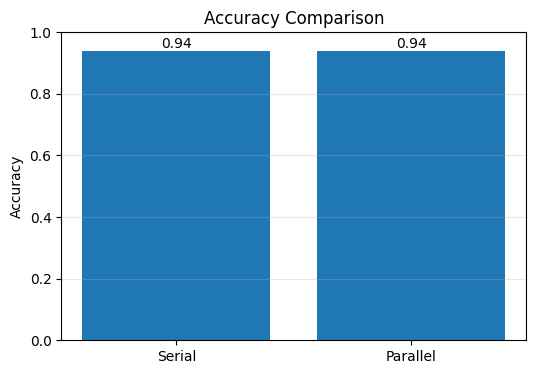

In [22]:
plt.figure(figsize=(6,4))

labels = ['Serial', 'Parallel']
values = [acc_s, acc_p]

plt.bar(labels, values)
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")

for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.show()

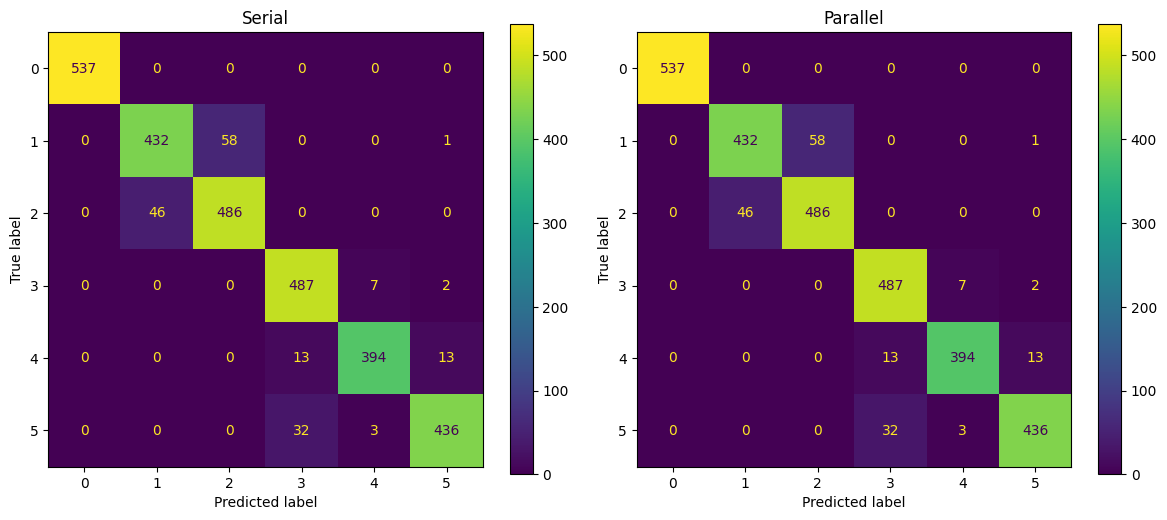

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12,5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_s, ax=axes[0])
axes[0].set_title("Serial")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_p, ax=axes[1])
axes[1].set_title("Parallel")

plt.tight_layout()
plt.show()

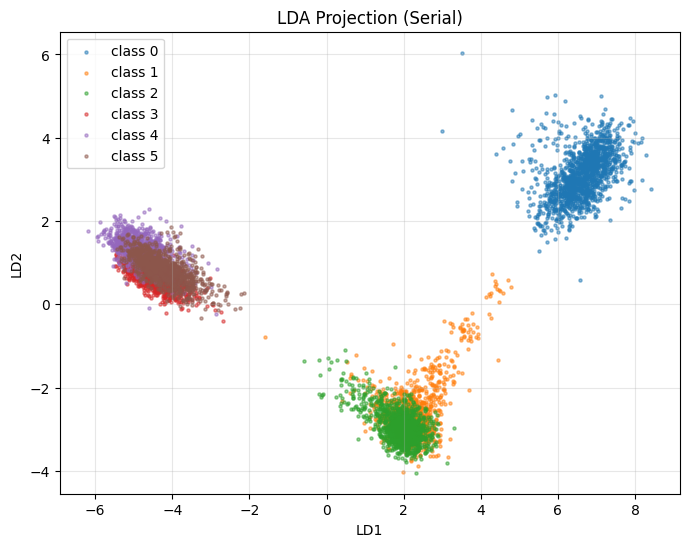

In [24]:
plt.figure(figsize=(8,6))

for c in np.unique(y_train):
    mask = y_train == c
    plt.scatter(Y_train_s[mask,0], Y_train_s[mask,1], s=5, alpha=0.5, label=f"class {c}")

plt.title("LDA Projection (Serial)")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

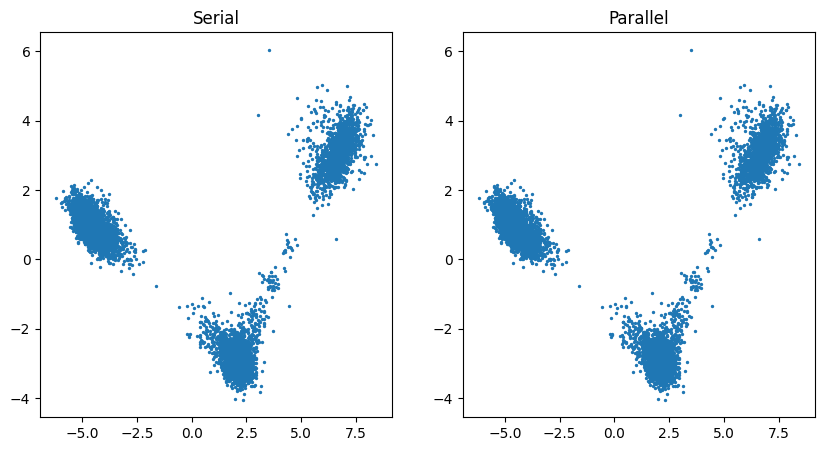

In [25]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.scatter(Y_train_s[:,0], Y_train_s[:,1], s=2)
plt.title("Serial")

plt.subplot(1,2,2)
plt.scatter(Y_train_p[:,0], Y_train_p[:,1], s=2)
plt.title("Parallel")

plt.show()